In [149]:
import math
import warnings
from typing import Tuple, Any, Dict

from matplotlib import pyplot as plt

import jax
from jax import numpy as jnp

from blueprint import Device
from blueprint.pulses import get_cos_pulse
from blueprint.drives import ChargeDrive
from blueprint.systems import Fluxonium, Resonator
from blueprint.couplings import ChargeCoupling
from blueprint.branches.quantum import get_branches

In [150]:
def get_figsize(
    columns: int = 1,
    fig_width: float | None = None,
    fig_height: float | None = None,
    width_scale: float = 1.0,
    height_scale: float = 1.0,
) -> Tuple[float, float]:
    """
    get_figsize Returns the figure size for a matplotlib plot that is
    consistent with the IEEE journal template.

    Parameters
    ----------
    columns : int, optional
        The number of text columns that the figure takes up, by default 1
    fig_width : float | None, optional
        The width of the figure in inches, by default None
    fig_height : float | None, optional
        The height of the figure in inches, by default None
    width_scale : float, optional
        A scale factor for the width of the figure, by default 1.0
    height_scale : float, optional
        A scale factor for the height of the figure, by default 1.0

    Returns
    -------
    Tuple[float, float]
        The width and height of the figure in inches.

    Raises
    ------
    ValueError
        If the number of columns is not 1 or 2.
    """

    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    if columns not in [1, 2]:
        raise ValueError("Plotting in three-column style is not supported")

    max_height = 8.0
    golden_ratio = 0.5 * (1 + math.sqrt(5))

    if not fig_width:
        fig_width = 3.4 if columns == 1 else 7
    # one-column width is ~8.6cm, double-column is ~17.8cm

    fig_height = fig_height or fig_width / golden_ratio  # height in inches

    if fig_height > max_height:
        warnings.warn(
            f"Figure height {fig_height} is too large, setting to {max_height}"
            "inches instead"
        )

    width = fig_width * width_scale
    height = fig_height * height_scale
    figsize = (width, height)
    return figsize


def get_rc_params(**kwargs: Any) -> Dict[str, Any]:
    """
    get_rc_params Returns the matplotlib rcParams for a plot that is consistent with the IEEE journal template.

    Parameters
    ----------
    **kwargs : Any
        Additional keyword arguments to pass to the rcParams. These will override the default values.
        The arguments that have pre-defined values are:
        - "axes.labelsize": 8
        - "axes.titlesize": 8
        - "legend.fontsize": 8
        - "xtick.labelsize": 8
        - "ytick.labelsize": 8
        - "text.usetex": False
        - "font.family": "serif"

    Returns
    -------
    Dict[str, Any]
        The dictionary of rcParams for the plot.
    """
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf
    params = {
        # "backend": "ps", # Commented out because of backened issues
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "text.usetex": False,  # This should ideally be True, but leads to issues in certain cases.
        "font.family": "serif",
    }
    params.update(kwargs)
    return params


In [151]:
USE_DOUBLE_PRECISION: bool = True
USE_GPU: bool = False
DEVICE_IND: int = 0

if USE_DOUBLE_PRECISION:
    jax.config.update("jax_enable_x64", True)  # Double precision

if USE_GPU:
    cuda_devices = jax.devices("cuda")
    if not cuda_devices:
        raise ValueError("No GPU devices found.")

    device = cuda_devices[DEVICE_IND]
    jax.config.update("jax_default_device", device)

In [152]:
# units
GHZ = 2 * math.pi
MHZ = 2 * 1e-3 * math.pi
FLUX_QUANTUM = 2 * math.pi

In [126]:
FLUXONIUM_LABEL: str = "fluxonium"
JOSEPHSON_ENERGY: float = 4.0 * GHZ
CHARGING_ENERGY: float = 1.0 * GHZ
INDUCTIVE_ENERGY: float = 1.0 * GHZ
EXT_FLUX: float = 0.5 * FLUX_QUANTUM
HARMONIC_CUTOFF: int = 1000
FLUXONIUM_DIM: int = 30

fluxonium = Fluxonium(
    label=FLUXONIUM_LABEL,
    josephson_energy=JOSEPHSON_ENERGY,
    charging_energy=CHARGING_ENERGY,
    inductive_energy=INDUCTIVE_ENERGY,
    ext_flux=EXT_FLUX,
    harmonic_cutoff=HARMONIC_CUTOFF,
    dim=FLUXONIUM_DIM,
)

In [127]:
print(f"Fluxonium label: {fluxonium.label}")
print(f"Charging energy: {fluxonium.charging_energy / GHZ:.3f} GHz")
print(f"Josephson energy: {fluxonium.josephson_energy / GHZ:.3f} GHz")
print(f"Inductive energy: {fluxonium.inductive_energy / GHZ:.3f} GHz")
print(f"External flux: {fluxonium.external_flux / FLUX_QUANTUM:.3f} Φ₀")
print(f"Harmonic cutoff: {fluxonium.harmonic_cutoff}")
print(f"Dimension: {fluxonium.dim}")

Fluxonium label: fluxonium
Charging energy: 1.000 GHz
Josephson energy: 4.000 GHz
Inductive energy: 1.000 GHz
External flux: 0.500 Φ₀
Harmonic cutoff: 1000
Dimension: 30


In [153]:
raise_op = fluxonium.get_raise_op()
print(f"Raising operator shape: {raise_op.shape}")
low_op = fluxonium.get_low_op()
print(f"Lowering operator shape: {low_op.shape}")

number_op = fluxonium.get_number_op()
print(f"Number operator shape: {number_op.shape}")
id_op = fluxonium.get_identity_op()
print(f"Identity operator shape: {id_op.shape}")

charge_op = fluxonium.get_charge_op()
print(f"Charge operator shape: {charge_op.shape}")
flux_op = fluxonium.get_flux_op()
print(f"Flux operator shape: {flux_op.shape}")

Raising operator shape: (30, 30)
Lowering operator shape: (30, 30)
Number operator shape: (30, 30)
Identity operator shape: (30, 30)
Charge operator shape: (30, 30)
Flux operator shape: (30, 30)


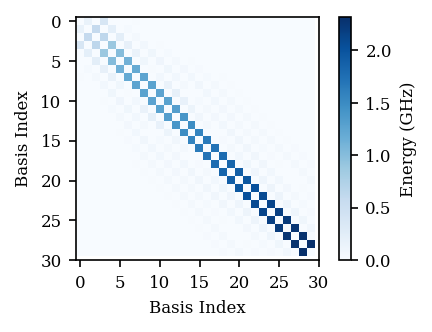

In [154]:
figsize = get_figsize()
rc_params = get_rc_params()

ticks = jnp.arange(0, FLUXONIUM_DIM + 1, 5)

with plt.rc_context(rc_params):
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    img = ax.imshow(jnp.abs(charge_op.imag), cmap="Blues")
    colorbar = fig.colorbar(img, ax=ax)
    colorbar.set_label("Energy (GHz)")
    ax.set_xticks(ticks)
    ax.set_xlabel("Basis Index")
    ax.set_yticks(ticks)
    ax.set_ylabel("Basis Index")
    plt.show()

In [155]:
print(fluxonium.is_diagonal)

True


In [156]:
hamiltonian = fluxonium.get_hamiltonian()

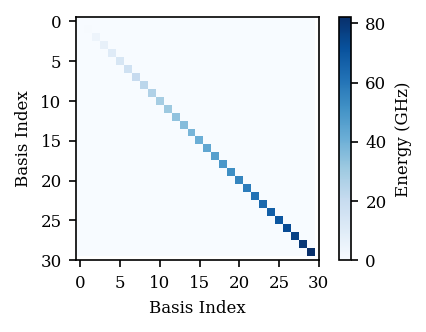

In [157]:
figsize = get_figsize()
rc_params = get_rc_params()

ticks = jnp.arange(0, FLUXONIUM_DIM + 1, 5)

with plt.rc_context(rc_params):
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    img = ax.imshow(hamiltonian / GHZ, cmap="Blues", vmin=0.0)
    colorbar = fig.colorbar(img, ax=ax)
    colorbar.set_label("Energy (GHz)")
    ax.set_xticks(ticks)
    ax.set_xlabel("Basis Index")
    ax.set_yticks(ticks)
    ax.set_ylabel("Basis Index")
    plt.show()

In [158]:
energies, states = fluxonium.get_eigenstates()

In [159]:
assert jnp.allclose(states, jnp.identity(FLUXONIUM_DIM))

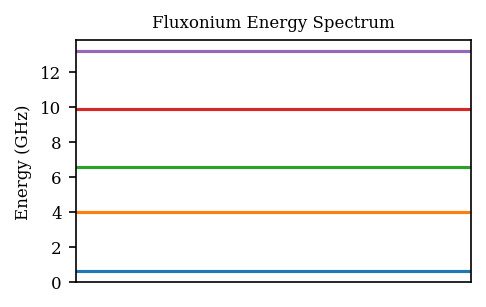

In [160]:
figsize = get_figsize()
rc_params = get_rc_params()

inds = [1, 2, 3, 4, 5]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

with plt.rc_context(rc_params):
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    
    for ind, color in zip(inds, colors):
        ax.axhline(
            energies[ind] / GHZ,
            linestyle="-",
            color=color,
            label=f"Level {ind}",
        )

    ax.xaxis.set_visible(False)
    ax.set_ylabel("Energy (GHz)")
    ax.set_title("Fluxonium Energy Spectrum")
    plt.show()

In [161]:
print(f"Fluxonium frequency: {fluxonium.fundamental_frequency / GHZ:.3f} GHz")
print(f"Fluxonium anharmonicity: {fluxonium.anharmonicity / MHZ:.3f} MHz")

Fluxonium frequency: 0.582 GHz
Fluxonium anharmonicity: 2806.738 MHz


In [137]:
print(f"Fluxonium frequency: {fluxonium.get_energy_diff(1, 0) / GHZ:.3f} GHz")

Fluxonium frequency: 0.582 GHz


In [139]:
DRIVE_LABEL: str = "fluxonium_drive"
DRIVE_AMPLITUDE: float = 150 * MHZ
DRIVE_PHASE: float = 0.0
DRIVE_FREQUENCY: float = 7.515 * GHZ

In [140]:
drive_pulse = get_cos_pulse(DRIVE_AMPLITUDE, DRIVE_FREQUENCY, DRIVE_PHASE)
drive = ChargeDrive(
    label=DRIVE_LABEL,
    pulse=drive_pulse,
)

In [141]:
drive_hamiltonian = drive.get_hamiltonian(fluxonium, 5.0)
print(f"Drive Hamiltonian shape: {drive_hamiltonian.shape}")

Drive Hamiltonian shape: (30, 30)


In [142]:
drive_timeqarray = drive.as_timeqarray(fluxonium)
print(drive_timeqarray)

ModulatedTimeQArray: shape=(30, 30), dims=(30,), dtype=complex128, layout=dense


In [144]:
hamiltonian_timeqarray = fluxonium.get_hamiltonian_timeqarray()
print(hamiltonian_timeqarray)

ConstantTimeQArray: shape=(30, 30), dims=(30,), dtype=float64, layout=dense


In [145]:
fluxonium.add_drive(drive.label, drive)
print(f"Fluxonium drives: {fluxonium.drives}")

Fluxonium drives: {'fluxonium_drive': ChargeDrive(
  label='fluxonium_drive',
  pulse=Partial(
    func=<PjitFunction of <function eval_cos_pulse at 0x339f2f600>>,
    args=(),
    keywords={
      'amplitude': 0.942477796076938,
      'frequency': 47.21813758345459,
      'phase': 0.0
    }
  )
)}


In [146]:
drive_timeqarray = fluxonium.get_drive_timeqarray()
print(drive_timeqarray)

SummedTimeQArray: shape=(30, 30), dims=(30,), dtype=complex128, layout=dense


# Embedded systems

In [162]:
FLUXONIUM_LABEL: str = "fluxonium"
JOSEPHSON_ENERGY: float = 4.0 * GHZ
CHARGING_ENERGY: float = 1.0 * GHZ
INDUCTIVE_ENERGY: float = 1.0 * GHZ
EXT_FLUX: float = 0.5 * FLUX_QUANTUM
HARMONIC_CUTOFF: int = 1000
FLUXONIUM_DIM: int = 30

fluxonium = Fluxonium(
    label=FLUXONIUM_LABEL,
    josephson_energy=JOSEPHSON_ENERGY,
    charging_energy=CHARGING_ENERGY,
    inductive_energy=INDUCTIVE_ENERGY,
    ext_flux=EXT_FLUX,
    harmonic_cutoff=HARMONIC_CUTOFF,
    dim=FLUXONIUM_DIM,
)

In [164]:
RES_LABEL: str = "resonator"
RES_FREQ: float = 7.5 * GHZ
RES_IMPEDANCE: float = 50.0
RES_DIM: int = 200

resonator = Resonator.from_frequency(
    label=RES_LABEL,
    frequency=RES_FREQ,
    impedance=RES_IMPEDANCE,
    dim=RES_DIM,
)

In [165]:
COUP_LABEL: str = "coupling"
COUP_STRENGTH: float = 120 * MHZ

coupling = ChargeCoupling(
    label=COUP_LABEL,
    strength=COUP_STRENGTH,
)

In [166]:
DEVICE_DIMS = (FLUXONIUM_DIM, RES_DIM)
DIM = FLUXONIUM_DIM * RES_DIM

In [167]:
fluxonium = fluxonium.embed(0, DEVICE_DIMS)
resonator = resonator.embed(1, DEVICE_DIMS)

In [168]:
fluxonium_hamiltonian = fluxonium.get_hamiltonian()
print(f"Fluxonium Hamiltonian shape: {fluxonium_hamiltonian.shape}")
resonator_hamiltonian = resonator.get_hamiltonian()
print(f"Resonator Hamiltonian shape: {resonator_hamiltonian.shape}")
bare_hamiltonian = fluxonium_hamiltonian + resonator_hamiltonian

Fluxonium Hamiltonian shape: (6000, 6000)
Resonator Hamiltonian shape: (6000, 6000)


In [169]:
coup_hamiltonian = coupling.get_hamiltonian(fluxonium, resonator)
print(f"Coupling Hamiltonian shape: {coup_hamiltonian.shape}")

Coupling Hamiltonian shape: (6000, 6000)


In [171]:
hamiltonian = bare_hamiltonian + coup_hamiltonian

In [172]:
_, fluxonium_states = fluxonium.get_eigenstates()
_, res_states = resonator.get_eigenstates()
res_ground_state = res_states[:, 0]

prod_states = jnp.kron(fluxonium_states, res_ground_state[:, None])

In [173]:
raise_op = resonator.get_raise_op()

energies, states = get_branches(
    hamiltonian=hamiltonian, raise_op=raise_op, prod_states=prod_states
)

In [174]:
energies = energies.reshape((FLUXONIUM_DIM, RES_DIM))
states = states.reshape((DIM, FLUXONIUM_DIM, RES_DIM))

In [175]:
disp_shift = 0.5 * jnp.abs(energies[1, 1] - energies[0, 1] - energies[1, 0])

In [176]:
print(f"Dispersive shift: {disp_shift / MHZ:.3f} MHz")

Dispersive shift: 8.379 MHz


In [177]:
fluxonium = Fluxonium(
    label=FLUXONIUM_LABEL,
    josephson_energy=JOSEPHSON_ENERGY,
    charging_energy=CHARGING_ENERGY,
    inductive_energy=INDUCTIVE_ENERGY,
    ext_flux=EXT_FLUX,
    harmonic_cutoff=HARMONIC_CUTOFF,
    dim=FLUXONIUM_DIM,
)

resonator = Resonator.from_frequency(
    label=RES_LABEL,
    frequency=RES_FREQ,
    impedance=RES_IMPEDANCE,
    dim=RES_DIM,
)

coupling = ChargeCoupling(
    label=COUP_LABEL,
    strength=COUP_STRENGTH,
)

systems = (fluxonium, resonator)
device = Device(systems=systems)
device.add_coupling("fluxonium", "resonator", coupling)

In [178]:
device_hamiltonian = device.get_hamiltonian()

In [179]:
assert jnp.allclose(hamiltonian, device_hamiltonian)

In [89]:
# raise_op = device["fluxonium"].get_raise_op()
# ...